# Model Inference — House Price Prediction
Load the best model from MLflow Model Registry and generate Kaggle submission.

In [21]:
import numpy as np
import pandas as pd
import mlflow
import dagshub

dagshub.init(repo_owner='aochi23', repo_name='ml_assn_01', mlflow=True)

Initialized MLflow to track repo "aochi23/ml_assn_01"

Repository aochi23/ml_assn_01 initialized!

## Load Test Data

In [22]:
test_df = pd.read_csv('D:/FreeUni/Semester_6/Machine Learning/house_prices/ml_assn/ml_assn_01/data/test.csv')
print(f'Test set shape: {test_df.shape}')
test_df.head()

Test set shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


## Apply the Same Preprocessing Pipeline
Must repeat exactly what was done in model_experiment.ipynb

In [23]:
submission_ids = test_df['Id'].copy()
test_df = test_df.drop(columns=['Id'])

In [24]:
train_df = pd.read_csv('D:/FreeUni/Semester_6/Machine Learning/house_prices/ml_assn/ml_assn_01/data/train.csv')

neighborhood_medians = train_df.groupby('Neighborhood')['LotFrontage'].median()
electrical_mode      = train_df['Electrical'].mode()[0]

none_columns = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
                'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtCond',
                'BsmtFinType1', 'BsmtExposure', 'BsmtQual', 'BsmtFinType2']

def fill_missing_values(X, neighborhood_medians, electrical_mode):
    X = X.copy()
    for col in none_columns:
        if col in X.columns:
            X[col] = X[col].fillna('None')

    X['GarageYrBlt'] = X['GarageYrBlt'].fillna(0)
    X['MasVnrArea']  = X['MasVnrArea'].fillna(0)
    X['LotFrontage'] = X['LotFrontage'].fillna(X['Neighborhood'].map(neighborhood_medians))
    X['LotFrontage'] = X['LotFrontage'].fillna(neighborhood_medians.median())
    X['Electrical']  = X['Electrical'].fillna(electrical_mode)

    cols_with_null = [col for col in X.columns if X[col].isnull().any()]
    print(f'Columns with remaining nulls: {cols_with_null}')

    for col in X.columns:
        if X[col].isnull().any():
            if X[col].dtype == 'object':
                X[col] = X[col].fillna(X[col].mode()[0] if not X[col].mode().empty else 'None')
            else:
                X[col] = X[col].fillna(X[col].median())
    return X

test_df = fill_missing_values(test_df, neighborhood_medians, electrical_mode)
print('Missing after fill:', test_df.isnull().sum().sum())

Columns with remaining nulls: ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'KitchenQual', 'Functional', 'GarageCars', 'GarageArea', 'SaleType']
Missing after fill: 0


In [25]:
def ordinal_encode(X):
    quality_map  = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
    quality_cols = ['GarageQual', 'GarageCond', 'PoolQC', 'ExterQual',
                    'ExterCond', 'BsmtCond', 'HeatingQC',
                    'KitchenQual', 'BsmtQual', 'FireplaceQu']
    for col in quality_cols:
        if col in X.columns:
            X[col] = X[col].map(quality_map)

    X['BsmtExposure']  = X['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
    bsmt_fin_map       = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
    X['BsmtFinType1']  = X['BsmtFinType1'].map(bsmt_fin_map)
    X['BsmtFinType2']  = X['BsmtFinType2'].map(bsmt_fin_map)
    X['GarageFinish']  = X['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})
    X['Fence']         = X['Fence'].map({'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4})
    X['Functional']    = X['Functional'].map(
        {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8})
    X['PavedDrive']    = X['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})
    X['LandSlope']     = X['LandSlope'].map({'Sev': 1, 'Mod': 2, 'Gtl': 3})
    X['LotShape']      = X['LotShape'].map({'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4})
    return X

test_df = ordinal_encode(test_df.copy())

In [26]:
from sklearn.model_selection import train_test_split

X_tr = train_df.drop(columns=['SalePrice', 'Id'])
y_tr = train_df['SalePrice']
X_tr, X_test , y_tr, y_test = train_test_split(X_tr, y_tr, test_size=0.2, random_state=42)

neighborhood_means = y_tr.groupby(X_tr['Neighborhood']).mean()

test_df['Neighborhood'] = test_df['Neighborhood'].map(neighborhood_means).fillna(neighborhood_means.mean())
test_df['MSSubClass'] = test_df['MSSubClass'].astype(str)

In [27]:
X_train_copy = X_tr.copy()
X_train_copy = fill_missing_values(X_train_copy, neighborhood_medians, electrical_mode)
X_train_copy = ordinal_encode(X_train_copy.copy())
X_train_copy['Neighborhood'] = X_train_copy['Neighborhood'].map(neighborhood_means).fillna(neighborhood_means.mean())
X_train_copy['MSSubClass'] = X_train_copy['MSSubClass'].astype(str)

ohe_columns  = [col for col in X_train_copy.columns if X_train_copy[col].dtype == 'object']
X_train_copy = pd.get_dummies(X_train_copy, columns=ohe_columns, dtype=int)
fitted_columns = X_train_copy.columns.tolist()

test_df = pd.get_dummies(test_df, columns=ohe_columns, dtype=int)
for col in fitted_columns:
    if col not in test_df.columns:
        test_df[col] = 0
test_df = test_df[fitted_columns]

print(f'Test shape after OHE: {test_df.shape}')

Columns with remaining nulls: []
Test shape after OHE: (1459, 214)


In [28]:
near_constant_cols = []
for col in X_train_copy.columns:
    top_freq = X_train_copy[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        near_constant_cols.append(col)

test_df = test_df.drop(columns=[c for c in near_constant_cols if c in test_df.columns])
print(f'Dropped {len(near_constant_cols)} near-constant cols. Test shape: {test_df.shape}')

Dropped 116 near-constant cols. Test shape: (1459, 98)


In [29]:
num_cols = [col for col in X_train_copy.columns if X_train_copy[col].dtype != 'object']
skewness = X_train_copy[num_cols].skew()
high_skew_cols = skewness[skewness > 0.75].index.tolist()

for col in high_skew_cols:
    if col in test_df.columns:
        test_df[col] = np.log1p(test_df[col])

print(f'Log-transformed {len(high_skew_cols)} skewed columns')

Log-transformed 161 skewed columns


In [30]:
def combine_some_columns(X):
    X['TotalSF']      = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']
    X['TotalBath']    = (X['FullBath'] + X['BsmtFullBath'] +
                         0.5 * X['HalfBath'] + 0.5 * X['BsmtHalfBath'])
    X['TotalPorch']   = (X['OpenPorchSF'] + X['EnclosedPorch'] + X['ScreenPorch'])
    X['HouseAge']     = X['YrSold'] - X['YearBuilt']
    X['RemodAge']     = X['YrSold'] - X['YearRemodAdd']
    X['IsRemodeled']  = (X['YearBuilt'] != X['YearRemodAdd']).astype(int)
    X['HasGarage']    = (X['GarageArea'] > 0).astype(int)
    X['HasFireplace'] = (X['Fireplaces'] > 0).astype(int)
    X['HasPorch']     = (X['TotalPorch'] > 0).astype(int)
    X['HasBsmt']      = (X['TotalBsmtSF'] > 0).astype(int)
    return X

combined_columns_drop = [
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
    'FullBath', 'BsmtFullBath', 'HalfBath', 'BsmtHalfBath',
    'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch',
    'YearBuilt', 'YearRemodAdd', 'YrSold'
]

test_df = combine_some_columns(test_df)
test_df = test_df.drop(columns=[c for c in combined_columns_drop if c in test_df.columns])

print(f'Final test shape: {test_df.shape}')

Final test shape: (1459, 95)


In [39]:
from sklearn.base import BaseEstimator, TransformerMixin

class IVSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.02):
        self.threshold = threshold
        self.iv_scores = {}
        self.selected_features = None
        self.median = None

    def compute_iv(self, X, y_binary, col):
        series = X[col]
        if series.nunique() > 10:
            series = pd.qcut(series, q=10, duplicates='drop')

        df = pd.DataFrame({"col": series, "target": y_binary})
        total_e  = y_binary.sum()
        total_ne = (1 - y_binary).sum()
        iv = 0
        for val, group in df.groupby("col", observed=True):
            e, ne   = group["target"].sum(), (1 - group["target"]).sum()
            dist_e  = (e  + 0.5) / (total_e  + 0.5)
            dist_ne = (ne + 0.5) / (total_ne + 0.5)
            iv     += (dist_e - dist_ne) * np.log(dist_e / dist_ne)

        return iv

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        self.median = y.median()
        y_binary = (y > self.median).astype(int)

        self.iv_scores = {}
        for col in X.columns:
            self.iv_scores[col] = self.compute_iv(X, y_binary, col)

        self.selected_features = [
            col for col, iv in self.iv_scores.items() if iv >= self.threshold
        ]
        #print(f"IVSelector kept: {len(self.selected_features)} features")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.selected_features]

In [40]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.85):
        self.threshold  = threshold
        self.features_to_drop = None
        self.selected_features = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).reset_index(drop=True)
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        self.features_to_drop = set()
        for col in upper.columns:
            if any(upper[col] > self.threshold):
                for partner in upper.index[upper[col] > self.threshold].tolist():
                    if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                        self.features_to_drop.add(col)
                    else:
                        self.features_to_drop.add(partner)

        self.selected_features = [
            col for col in X.columns if col not in self.features_to_drop
        ]
        #print(f"CorrelationFilter dropped: {len(self.features_to_drop)}")
        #print(f"CorrelationFilter kept:    {len(self.selected_features)}")

        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.selected_features]

## Load Best Model from MLflow Model Registry

In [55]:
import mlflow
import skops.io as sio
from skops.io import get_untrusted_types


run_id = '9fb4f8f3dca94ea4860ab7f31e305909'

model_path = mlflow.artifacts.download_artifacts(
    run_id=run_id,
    artifact_path="best_model.skops"
)

unknown_types = get_untrusted_types(file=model_path)
print(f'Trusting types: {unknown_types}')

best_model = sio.load(model_path, trusted=unknown_types)
print('Model loaded')
print(type(best_model))

Trusting types: ['__main__.CorrelationFilter', '__main__.IVSelector', 'sklearn.utils._bunch.Bunch']
Model loaded
<class 'sklearn.pipeline.Pipeline'>


In [56]:
print(best_model)

Pipeline(steps=[('model',
                 StackingRegressor(cv=5,
                                   estimators=[('ridge_10_iv',
                                                Pipeline(steps=[('selector',
                                                                 IVSelector()),
                                                                ('scaler',
                                                                 StandardScaler()),
                                                                ('model',
                                                                 Ridge(alpha=10))])),
                                               ('lasso_001_corr',
                                                Pipeline(steps=[('selector',
                                                                 CorrelationFilter()),
                                                                ('scaler',
                                                                 StandardScaler()),
     

## Generate Predictions

In [45]:
preds_log = best_model.predict(test_df)
preds = np.expm1(preds_log)

print(f'Predictions shape: {preds.shape}')
print(f'Price range: ${preds.min():,.0f} — ${preds.max():,.0f}')
print(f'Mean predicted price: ${preds.mean():,.0f}')

Predictions shape: (1459,)
Price range: $53,282 — $479,473
Mean predicted price: $177,598


In [53]:
submission = pd.DataFrame({
    'Id':        submission_ids.values,
    'SalePrice': preds
})

output_path = 'submission_final.csv'
submission.to_csv(output_path, index=False)

print(f'Submission saved to: {output_path}')
print(f'Total rows: {len(submission)}')
submission.head(10)

Submission saved to: submission_final.csv
Total rows: 1459


,Id,SalePrice
0,1461,115818.457101
1,1462,153472.105615
2,1463,184652.668504
3,1464,190598.072024
4,1465,201399.868562
5,1466,177582.940652
6,1467,179988.012348
7,1468,170114.252211
8,1469,193837.095617
9,1470,119797.697644


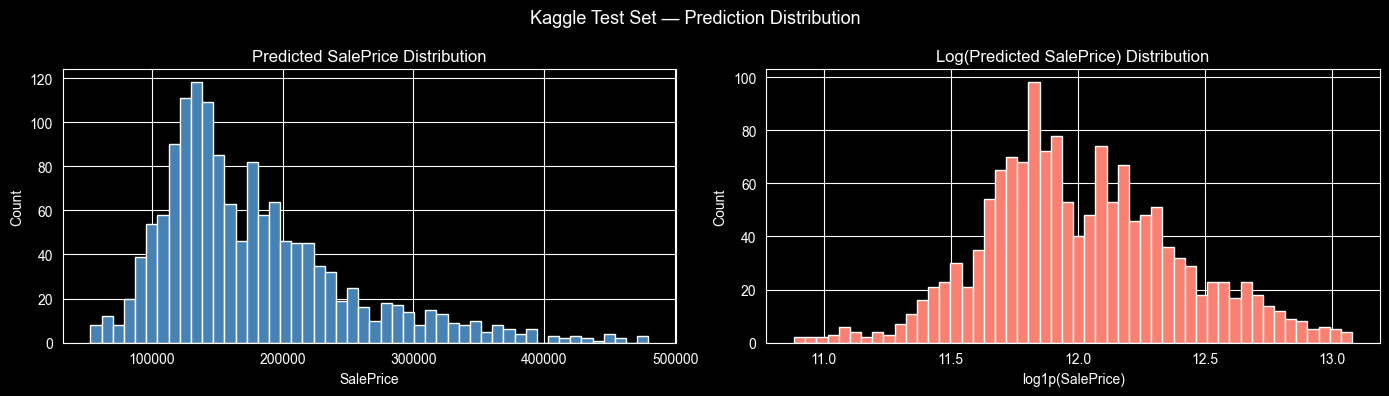

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(preds, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Predicted SalePrice Distribution')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(preds), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Log(Predicted SalePrice) Distribution')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Count')

plt.suptitle('Kaggle Test Set — Prediction Distribution', fontsize=13)
plt.tight_layout()
plt.show()